# Input File

In [ ]:
# === Config Cell ===
# Path to cleaned dataset
DATA_PATH = "output/emotions_clean.csv"

# Random seed for reproducibility
RAND = 42

# Label mapping
LABEL_MAP = {0:"Sadness",1:"Joy",2:"Love",3:"Anger",4:"Fear",5:"Surprise"}

## Logistic Regression

Logistic Regression is a widely used supervised learning algorithm for **binary and multi-class classification**.  
Instead of predicting continuous values (like Linear Regression), it predicts the **probability** of a sample belonging to a certain class using the **sigmoid function**.  

- It learns a set of **weights** for input features to best separate the classes.  
- In text classification, features are often extracted using **TF-IDF** or **word embeddings**, and Logistic Regression is used to classify text into categories (e.g., emotions, sentiments).  

**Advantages:**
- Simple and interpretable model.  
- Performs well on linearly separable data.  
- Efficient to train, even on large datasets.  

**Limitations:**
- Assumes a linear relationship between features and the log-odds of the outcome.  
- May underperform compared to more complex models (e.g., deep learning, ensemble methods) when data has complex patterns.  

Samples: 
  train: 237301 
  val  : 50850 
  test : 50851

Validation comparison (C → Macro-F1 / Accuracy):
  C=0.5  macroF1=0.9479  acc=0.9583
  C=1.0  macroF1=0.9527  acc=0.9624
  C=2.0  macroF1=0.9553  acc=0.9648
  C=4.0  macroF1=0.9579  acc=0.9667

Best C on validation: 4.0 (macroF1=0.9579)


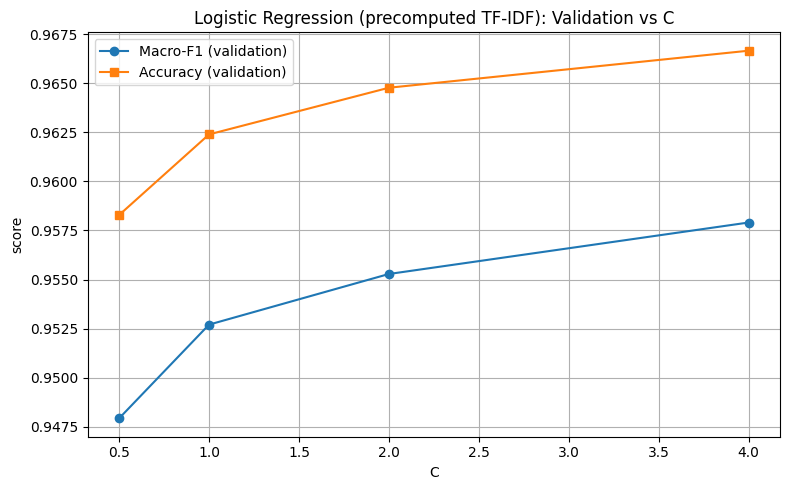


=== Logistic Regression — Final Test Report ===
              precision    recall  f1-score   support

           0     0.9776    0.9681    0.9728     15538
           1     0.9751    0.9701    0.9726     17878
           2     0.9344    0.9483    0.9413      3426
           3     0.9573    0.9653    0.9613      7148
           4     0.9574    0.9595    0.9584      5478
           5     0.8930    0.9718    0.9307      1383

    accuracy                         0.9662     50851
   macro avg     0.9491    0.9638    0.9562     50851
weighted avg     0.9665    0.9662    0.9663     50851



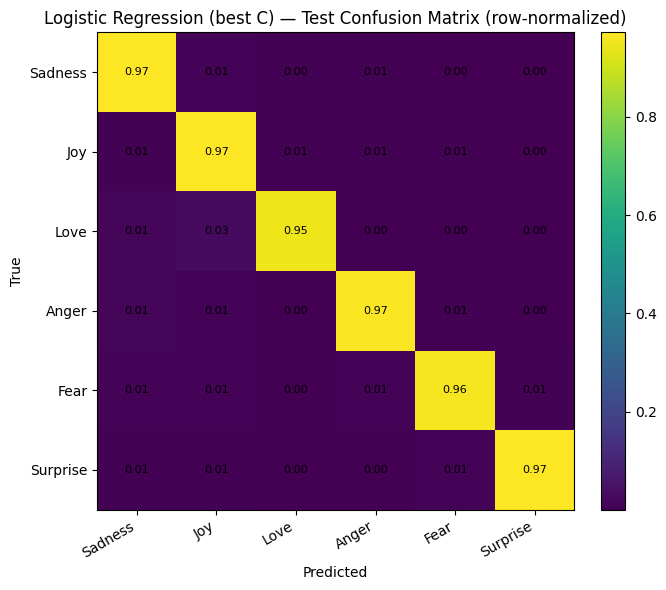

Saved: /kaggle/working/logreg_best_model.pkl

=== Sampled Test Predictions (10 records) ===
Idx  4370 | True: Sadness  | Pred: Sadness  | ✓
Idx  4537 | True: Sadness  | Pred: Sadness  | ✓
Idx  4789 | True: Sadness  | Pred: Sadness  | ✓
Idx 10244 | True: Fear     | Pred: Fear     | ✓
Idx 22017 | True: Sadness  | Pred: Sadness  | ✓
Idx 22314 | True: Fear     | Pred: Fear     | ✓
Idx 33281 | True: Joy      | Pred: Joy      | ✓
Idx 35460 | True: Sadness  | Pred: Sadness  | ✓
Idx 39350 | True: Sadness  | Pred: Sadness  | ✓
Idx 43657 | True: Joy      | Pred: Joy      | ✓


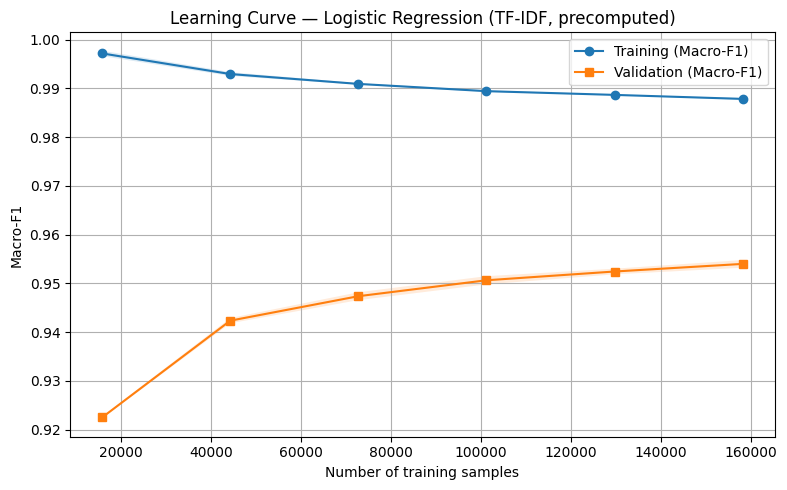

In [ ]:
# === Logistic Regression on precomputed TF-IDF: tune C, plot, retrain, test, save, learning curve ===
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import vstack

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

# --- Load precomputed features/labels ---
X_train = sparse.load_npz("output/X_train_tfidf.npz")
X_val   = sparse.load_npz("output/X_val_tfidf.npz")
X_test  = sparse.load_npz("output/X_test_tfidf.npz")
y_train = np.load("output/y_train.npy")
y_val   = np.load("output/y_val.npy")
y_test  = np.load("output/y_test.npy")

print("Samples:",
      "\n  train:", len(y_train),
      "\n  val  :", len(y_val),
      "\n  test :", len(y_test))

# --- Hyperparameter sweep on validation ---
C_GRID = [0.5, 1.0, 2.0, 4.0]
records = []  # (C, macroF1, acc)
best_C, best_f1 = None, -1.0

for C in C_GRID:
    clf = LogisticRegression(
        C=C,
        max_iter=2000,
        solver="liblinear",
        multi_class="ovr",
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_train, y_train)
    yv = clf.predict(X_val)
    f1m = f1_score(y_val, yv, average="macro")
    acc = accuracy_score(y_val, yv)
    records.append((C, f1m, acc))
    if f1m > best_f1:
        best_f1, best_C = f1m, C

print("\nValidation comparison (C → Macro-F1 / Accuracy):")
for C, f1m, acc in records:
    print(f"  C={C:<3}  macroF1={f1m:.4f}  acc={acc:.4f}")
print(f"\nBest C on validation: {best_C} (macroF1={best_f1:.4f})")

# --- Plot validation sweep ---
records_sorted = sorted(records, key=lambda x: x[0])
cs_plot  = [r[0] for r in records_sorted]
f1_plot  = [r[1] for r in records_sorted]
acc_plot = [r[2] for r in records_sorted]

plt.figure(figsize=(8,5))
plt.plot(cs_plot, f1_plot, marker="o", label="Macro-F1 (validation)")
plt.plot(cs_plot, acc_plot, marker="s", label="Accuracy (validation)")
plt.xlabel("C"); plt.ylabel("score")
plt.title("Logistic Regression (precomputed TF-IDF): Validation vs C")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# --- Retrain on Train+Val with best C ---
X_trval = vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

final_lr = LogisticRegression(
    C=best_C,
    max_iter=2000,
    solver="liblinear",
    multi_class="ovr",
    class_weight="balanced",
    random_state=42
)
final_lr.fit(X_trval, y_trval)

# --- Final test evaluation ---
yt = final_lr.predict(X_test)
print("\n=== Logistic Regression — Final Test Report ===")
print(classification_report(y_test, yt, digits=4))

# Confusion matrix (row-normalized)
LABEL_MAP = {0:"Sadness",1:"Joy",2:"Love",3:"Anger",4:"Fear",5:"Surprise"}
cm = confusion_matrix(y_test, yt, labels=[0,1,2,3,4,5])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5,6))
im = ax.imshow(cm_norm, interpolation='nearest')
ax.set_title("Logistic Regression (best C) — Test Confusion Matrix (row-normalized)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels([LABEL_MAP[i] for i in range(6)], rotation=30, ha="right")
ax.set_yticklabels([LABEL_MAP[i] for i in range(6)])
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# --- Save the trained classifier (model-only) ---
joblib.dump(final_lr, "output/logreg_best_model.pkl")
print("Saved: output/logreg_best_model.pkl")

# ===============================
# Show 10 test samples with predictions 
# ===============================
N_SHOW = 10
rng = np.random.default_rng(42)  # reproducible sampling
indices = np.sort(rng.choice(len(y_test), size=N_SHOW, replace=False))

print(f"\n=== Sampled Test Predictions ({N_SHOW} records) ===")
for i in indices:
    true_label = LABEL_MAP[int(y_test[i])]
    pred_label = LABEL_MAP[int(yt[i])]
    correct = "✓" if true_label == pred_label else "✗"
    print(f"Idx {i:5d} | True: {true_label:8} | Pred: {pred_label:8} | {correct}")
    
# =======================
# === Learning Curve  ===
# =======================
# We compute learning curves directly on the precomputed training matrix.
# (Estimator is the classifier only; features are already TF-IDF.)
lc_clf = LogisticRegression(
    C=best_C,
    max_iter=2000,
    solver="liblinear",
    multi_class="ovr",
    class_weight="balanced",
    random_state=42
)

train_sizes = np.linspace(0.1, 1.0, 6)  # 10%, 28%, ..., 100%
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=lc_clf,
    X=X_train,          # use only the TRAIN split
    y=y_train,
    cv=3,               # 3-fold CV within the train split
    scoring="f1_macro",
    train_sizes=train_sizes,
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, train_mean, marker="o", label="Training (Macro-F1)")
plt.fill_between(train_sizes_abs, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.plot(train_sizes_abs, val_mean, marker="s", label="Validation (Macro-F1)")
plt.fill_between(train_sizes_abs, val_mean-val_std, val_mean+val_std, alpha=0.15)
plt.xlabel("Number of training samples")
plt.ylabel("Macro-F1")
plt.title("Learning Curve — Logistic Regression (TF-IDF, precomputed)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()